Loading SampleSuperstore.csv

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("SampleSuperstore.csv")
print(df.head())

        Ship Mode    Segment        Country             City       State  \
0    Second Class   Consumer  United States        Henderson    Kentucky   
1    Second Class   Consumer  United States        Henderson    Kentucky   
2    Second Class  Corporate  United States      Los Angeles  California   
3  Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4  Standard Class   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region         Category Sub-Category     Sales  Quantity  \
0        42420  South        Furniture    Bookcases  261.9600         2   
1        42420  South        Furniture       Chairs  731.9400         3   
2        90036   West  Office Supplies       Labels   14.6200         2   
3        33311  South        Furniture       Tables  957.5775         5   
4        33311  South  Office Supplies      Storage   22.3680         2   

   Discount    Profit  
0      0.00   41.9136  
1      0.00  219.5820  
2      0.00    6.871

Inspect rows, columns, and data types

In [ ]:
print(df.shape)

(9994, 13)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB
None


Check for missing values and Remove duplicates

In [ ]:
print(df.isnull().sum())

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [ ]:
print(df.duplicated().sum())

17


In [ ]:
df[df.duplicated()]

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
950,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432
3406,Standard Class,Home Office,United States,Columbus,Ohio,43229,East,Furniture,Chairs,281.372,2,0.3,-12.0588
3670,Standard Class,Consumer,United States,Salem,Oregon,97301,West,Office Supplies,Paper,10.368,2,0.2,3.6288
4117,Standard Class,Consumer,United States,Los Angeles,California,90036,West,Office Supplies,Paper,19.440,3,0.0,9.3312
4553,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,12.840,3,0.0,5.7780
5905,Same Day,Home Office,United States,San Francisco,California,94122,West,Office Supplies,Labels,41.400,4,0.0,19.8720
6146,Standard Class,Corporate,United States,San Francisco,California,94122,West,Office Supplies,Art,11.760,4,0.0,3.1752
6334,Standard Class,Consumer,United States,New York City,New York,10011,East,Office Supplies,Paper,49.120,4,0.0,23.0864
6357,Standard Class,Corporate,United States,Seattle,Washington,98103,West,Office Supplies,Paper,25.920,4,0.0,12.4416
7608,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,25.920,4,0.0,12.4416


In [ ]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


Rename Columns

In [ ]:
df.columns

Index(['Ship_Mode', 'Segment', 'Country', 'City', 'State', 'Postal_Code',
       'Region', 'Category', 'Sub_Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [ ]:
df.rename(columns={
    'Ship Mode':'Ship_Mode',
    'Postal Code':'Postal_Code',
    'Sub-Category':'Sub_Category'
}, inplace=True)

In [ ]:
df.columns

Index(['Ship_Mode', 'Segment', 'Country', 'City', 'State', 'Postal_Code',
       'Region', 'Category', 'Sub_Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

Standardize Text Values

In [ ]:
df['Category'] = df['Category'].str.title()
df['Region'] = df['Region'].str.title()
df['Segment'] = df['Segment'].str.title()
df['Ship_Mode'] = df['Ship_Mode'].str.title()
df['Country'] = df['Country'].str.title()
df['City'] = df['City'].str.title()
df['State'] = df['State'].str.title()
df['Sub_Category'] = df['Sub_Category'].str.title()

In [ ]:
df['Category'] = df['Category'].str.strip()
df['Region'] = df['Region'].str.strip()
df['Segment'] = df['Segment'].str.strip()
df['Ship_Mode'] = df['Ship_Mode'].str.strip()
df['Country'] = df['Country'].str.strip()
df['City'] = df['City'].str.strip()
df['State'] = df['State'].str.strip()
df['Sub_Category'] = df['Sub_Category'].str.strip()

Detect Outliers (Box Plot)

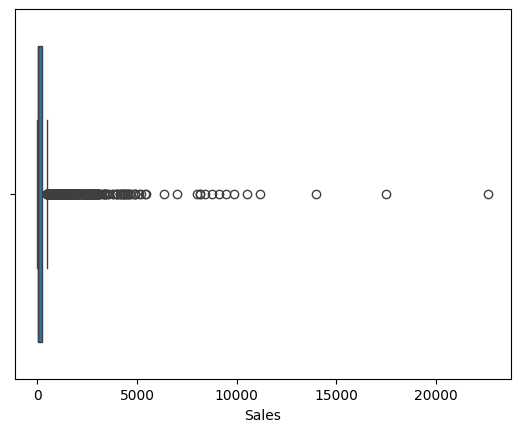

In [ ]:
sns.boxplot(x=df['Sales'])
plt.show()

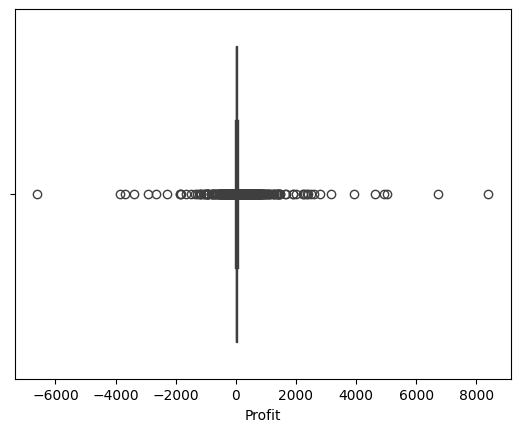

In [ ]:
sns.boxplot(x=df['Profit'])
plt.show()

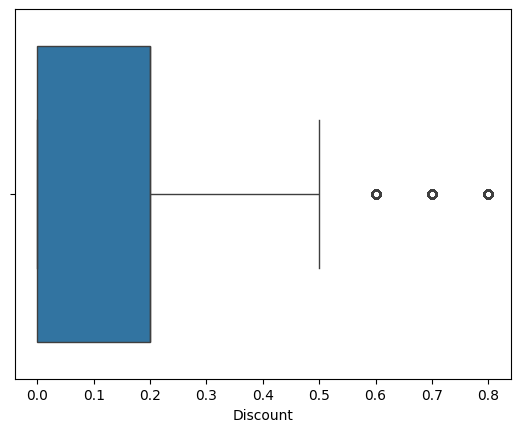

In [ ]:
sns.boxplot(x=df['Discount'])
plt.show()

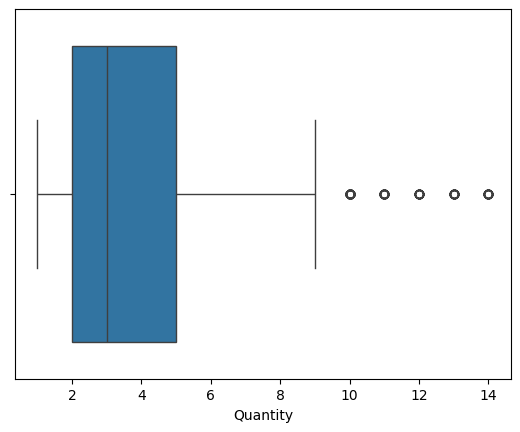

In [ ]:
sns.boxplot(x=df['Quantity'])
plt.show()

Check & Count Unique Values

In [77]:
print(df['Category'].unique())
print(df['Region'].unique())
print(df['Segment'].unique())
print(df['Ship_Mode'].unique())

['Furniture' 'Office Supplies' 'Technology']
['South' 'West' 'Central' 'East']
['Consumer' 'Corporate' 'Home Office']
['Second Class' 'Standard Class' 'First Class' 'Same Day']


In [78]:
df.nunique()

,0
Ship_Mode,4
Segment,3
Country,1
City,531
State,49
Postal_Code,631
Region,4
Category,3
Sub_Category,17
Sales,5825


Save Cleaned Dataset

In [79]:
df.to_csv("Cleaned_Superstore.csv", index=False)